# E-Commerce Sales Analytics Case Study

> 1. Load the CSV file using Pandas.

In [6]:
import pandas as pd

temp = pd.read_csv(
    "../datasets/Ecommerce_Sales_500_Records.csv"
)

temp.head()

,Order_ID,Month,Product,Category,Quantity,Price
0,1001,Sep,Shoes,Fashion,16,2000
1,1002,Nov,Laptop,Electronics,37,50000
2,1003,Dec,Laptop,Electronics,45,50000
3,1004,Dec,Laptop,Electronics,11,50000
4,1005,Nov,Watch,Fashion,47,3000


> 2. Display first 10 records.

In [7]:
print(temp.head(10))

   Order_ID Month       Product     Category  Quantity  Price
0      1001   Sep         Shoes      Fashion        16   2000
1      1002   Nov        Laptop  Electronics        37  50000
2      1003   Dec        Laptop  Electronics        45  50000
3      1004   Dec        Laptop  Electronics        11  50000
4      1005   Nov         Watch      Fashion        47   3000
5      1006   Nov  Refrigerator   Appliances        22  25000
6      1007   Jul         Watch      Fashion        47   3000
7      1008   Oct            TV  Electronics        43  35000
8      1009   Sep            TV  Electronics        35  35000
9      1010   May            TV  Electronics        39  35000


> 3. Check missing values and data types.

In [8]:
print(temp.dtypes)

Order_ID    int64
Month         str
Product       str
Category      str
Quantity    int64
Price       int64
dtype: object


In [9]:
temp.isnull().sum()

Order_ID    0
Month       0
Product     0
Category    0
Quantity    0
Price       0
dtype: int64

In [10]:
temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order_ID  500 non-null    int64
 1   Month     500 non-null    str  
 2   Product   500 non-null    str  
 3   Category  500 non-null    str  
 4   Quantity  500 non-null    int64
 5   Price     500 non-null    int64
dtypes: int64(3), str(3)
memory usage: 23.6 KB


> 4. Create Revenue column (Quantity × Price)

In [11]:
temp["Revenue"] = temp["Quantity"] * temp["Price"]
temp

,Order_ID,Month,Product,Category,Quantity,Price,Revenue
0,1001,Sep,Shoes,Fashion,16,2000,32000
1,1002,Nov,Laptop,Electronics,37,50000,1850000
2,1003,Dec,Laptop,Electronics,45,50000,2250000
3,1004,Dec,Laptop,Electronics,11,50000,550000
4,1005,Nov,Watch,Fashion,47,3000,141000
...,...,...,...,...,...,...,...
495,1496,Jul,Laptop,Electronics,42,50000,2100000
496,1497,Jan,Watch,Fashion,18,3000,54000
497,1498,Jan,Watch,Fashion,20,3000,60000
498,1499,Feb,Watch,Fashion,20,3000,60000


In [12]:
print(temp[['Quantity', 'Price', 'Revenue']].head())

   Quantity  Price  Revenue
0        16   2000    32000
1        37  50000  1850000
2        45  50000  2250000
3        11  50000   550000
4        47   3000   141000


In [13]:
MonthlySales = temp.groupby('Month')['Revenue'].sum()
MonthlySales

Month
Apr    24352000
Aug    20529000
Dec    13550000
Feb    25194000
Jan    37255000
Jul    25209000
Jun    17918000
Mar    18593000
May    30206000
Nov    23013000
Oct    21343000
Sep    31999000
Name: Revenue, dtype: int64

> 5. Calculate total revenue.

In [14]:
TotalRevenue = temp["Revenue"].sum()

In [15]:
TotalRevenue

np.int64(289161000)

> 6. Find top 5 products by revenue.

In [16]:
top5 = temp.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head()
print(top5)

Product
Laptop          112100000
TV               85470000
Refrigerator     49250000
Mobile           32265000
Watch             6528000
Name: Revenue, dtype: int64


> 7. Find category-wise revenue.

In [17]:
Revenue = temp.groupby("Category")["Revenue"].sum()

In [18]:
Revenue

Category
Appliances      49250000
Electronics    229835000
Fashion         10076000
Name: Revenue, dtype: int64

> 8. Find monthly sales trend.

In [19]:
month = temp.groupby("Month")["Revenue"].sum().sort_values(ascending=False)
month

Month
Jan    37255000
Sep    31999000
May    30206000
Jul    25209000
Feb    25194000
Apr    24352000
Nov    23013000
Oct    21343000
Aug    20529000
Mar    18593000
Jun    17918000
Dec    13550000
Name: Revenue, dtype: int64

> 9. Calculate mean, median, and standard deviation using NumPy.

In [20]:
import numpy as np 

In [21]:
np.mean(temp["Revenue"])

np.float64(578322.0)

In [22]:
np.median(temp['Revenue'])

np.float64(355000.0)

In [23]:
np.std(temp['Revenue'])

np.float64(624625.1790602105)

> 10. Create line chart, bar chart, pie chart, and histogram using Matplotlib.

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Chart

<BarContainer object of 500 artists>

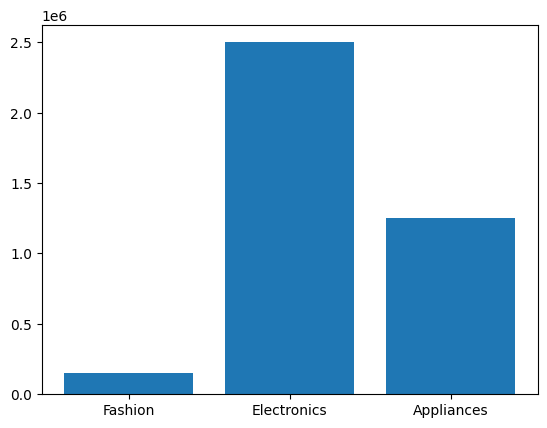

In [25]:
plt.bar(temp['Category'],temp['Revenue'])

# Pie Chart

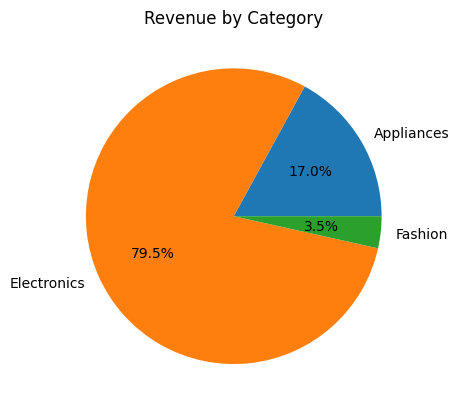

In [26]:
Revenue.plot(kind='pie',autopct='%1.1f%%')
plt.title("Revenue by Category")
plt.ylabel("")
plt.show()

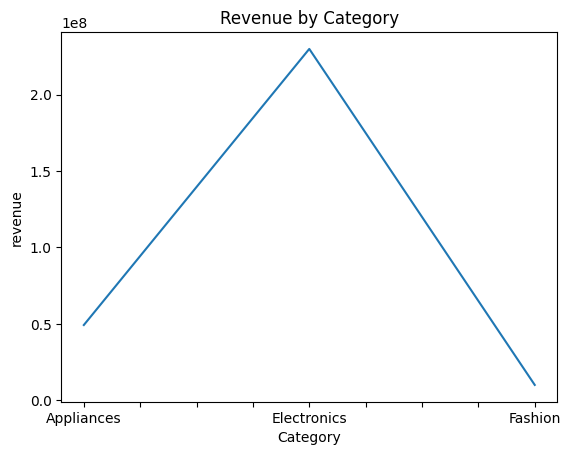

In [27]:
Revenue.plot(kind='line')
plt.title("Revenue by Category")
plt.ylabel("revenue")
plt.show()

# Line Chart

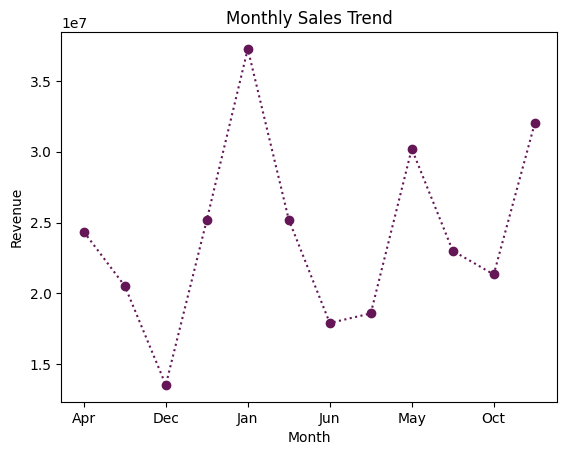

In [28]:
MonthlySales.plot(kind='line', marker='o',color = "#641656",linestyle = 'dotted')
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

# Histograph

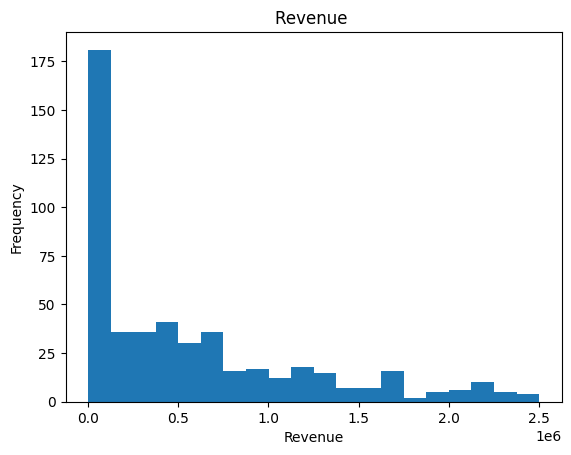

In [29]:
plt.hist(temp["Revenue"], bins=20)
plt.title("Revenue ")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [30]:
temp

,Order_ID,Month,Product,Category,Quantity,Price,Revenue
0,1001,Sep,Shoes,Fashion,16,2000,32000
1,1002,Nov,Laptop,Electronics,37,50000,1850000
2,1003,Dec,Laptop,Electronics,45,50000,2250000
3,1004,Dec,Laptop,Electronics,11,50000,550000
4,1005,Nov,Watch,Fashion,47,3000,141000
...,...,...,...,...,...,...,...
495,1496,Jul,Laptop,Electronics,42,50000,2100000
496,1497,Jan,Watch,Fashion,18,3000,54000
497,1498,Jan,Watch,Fashion,20,3000,60000
498,1499,Feb,Watch,Fashion,20,3000,60000
